[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/Hbretonniere/VHIO_academy_DL_Intro_Course/blob/main/notebooks/4-rna_auto_encoder.ipynb)

# #4 Unsupervised Auto-Encoder for gene expression

In this notebook, we are training an auto-encoder to compress gene expression in a breast cancer experiment.

In [1]:
import pandas as pd
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch.nn as nn
from torchinfo import summary


Fixing the seeds for replicability

In [2]:
seed = 50

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

## Data
Out data comes from TCGA, it's the gene expression of BRCA patients, log2 transformed.

In [3]:
path = '../data'

In [4]:
# ## If you are in google collab, uncomment this cell and run it:
# ## It will ask you to uplad a file, upload TCGA_rna.tsv and BRCA_annotations.tsv from the local data folder

# from google.colab import files
# uploaded = files.upload()
# path = '.'


In [5]:
data = pd.read_csv(f'{path}/TCGA_rna.tsv', index_col=0)
print(data.shape)
data.head()

(1073, 14151)


,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000278540,ENSG00000278570,ENSG00000278588,ENSG00000278619,ENSG00000278637,ENSG00000278705,ENSG00000278828,ENSG00000278845,ENSG00000278889,ENSG00000280670
TCGA-A2-A0CU-01A-12R-A034-07,4.691824,0.418481,4.919978,4.202941,3.026890,2.048943,5.738018,4.798743,4.533073,4.902648,...,7.287720,0.909771,-4.829332,3.642508,-5.869850,-5.869850,0.809190,5.717847,-5.869850,2.527248
TCGA-PL-A8LV-01A-21R-A41B-07,5.550574,-4.764376,4.849478,4.486026,3.503503,4.720707,5.061717,5.240700,4.545636,4.572156,...,6.193004,-1.980344,-4.145903,2.853027,-4.764376,-4.764376,1.482316,4.821616,-5.869850,1.522431
TCGA-BH-A0BC-01A-22R-A084-07,4.185385,0.510905,4.736422,4.455000,3.778220,4.213636,5.889652,5.901026,4.910096,5.123228,...,5.364725,-1.186219,-5.869850,1.162445,-5.869850,-5.869850,-3.649802,4.821089,-5.869850,1.860194
TCGA-AR-A1AX-01A-11R-A12P-07,4.313417,-4.910470,4.766316,4.699734,3.539703,3.811043,6.178000,4.933474,4.787563,5.679391,...,7.890383,-0.664692,-4.910470,2.503301,-5.869850,-4.910470,2.108746,5.002699,-5.869850,1.868287
TCGA-AC-A2FO-01A-11R-A180-07,6.353198,-0.577419,4.971040,4.791995,2.875439,3.540365,6.737507,5.342543,4.218174,5.409990,...,6.945120,-0.540888,-5.869850,3.044239,-5.869850,-5.869850,2.137335,5.342543,-4.866239,0.613016


## Ground truth
We don't need ground truth!!

## Normalisation
Our data is already log2 transform, we are just going to subtract the mean and divide mby the standard deviation

In [6]:
x = data.values

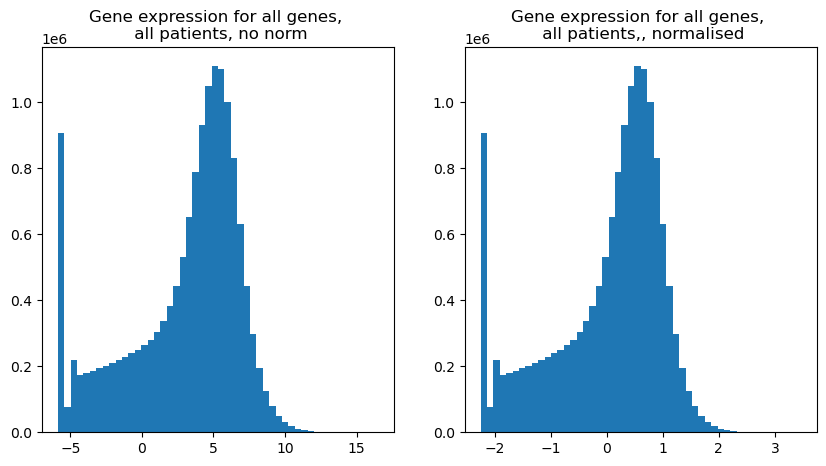

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(x.ravel(), bins=50)
x_norm = (x - np.mean(x)) / np.std(x)
ax[1].hist(x_norm.ravel(), bins=50)
ax[0].set_title('Gene expression for all genes, \n all patients, no norm')
ax[1].set_title('Gene expression for all genes, \n all patients,, normalised');

## Data preparation
As we are training an unsupervised model, we don't necessarly need a validation and test set. Our model will be specialised to our data, but it does not affect the fact that we can use the embeddings for further downstream analysis.

Here again, we transform our data to torch tensors.batch them.

In [ ]:
x_train = torch.from_numpy(x_norm).float()

## Model definition
We define our model: 
We have an Encoder and a Decoder, both made of mirrored neural networks.

The encoder is made of 4 layers, of 512, 256, 256, and latent_space_dim neurons, and ReLU activations.
The decoder is also made of 4 layers, of 256, 256, 512 and n_genes neurons, with ReLU except for the last layer.

The model is big, it starts to be long to train on CPU...

In [10]:
class RNAE(nn.Module):
    def __init__(self, LS_dim):
        super().__init__()

        self.Encoder = nn.Sequential(

            nn.Linear(14151, 512),
            nn.BatchNorm1d(512, momentum=0.01, eps=0.001),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256, momentum=0.01, eps=0.001),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256, momentum=0.01, eps=0.001),
            nn.ReLU(),

            nn.Linear(256, LS_dim),
            nn.BatchNorm1d(LS_dim, momentum=0.01, eps=0.001),
            nn.ReLU(),

        )

        self.Decoder = nn.Sequential(
            nn.Linear(LS_dim, 256),
            nn.BatchNorm1d(256, momentum=0.01, eps=0.001),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256, momentum=0.01, eps=0.001),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256, momentum=0.01, eps=0.001),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512, momentum=0.01, eps=0.001),
            nn.ReLU(),

            nn.Linear(512, 14151)

        )

    def forward(self, x):
        x = self.Encoder(x)
        x = self.Decoder(x)
        return x

In [11]:
LS_dim = 64
model = RNAE(LS_dim)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params} ...")


Total parameters: 15003399 ...


In [12]:
summary(model, input_size=(32, x.shape[1]))

Layer (type:depth-idx)                   Output Shape              Param #
RNAE                                     [32, 14151]               --
├─Sequential: 1-1                        [32, 64]                  --
│    └─Linear: 2-1                       [32, 512]                 7,245,824
│    └─BatchNorm1d: 2-2                  [32, 512]                 1,024
│    └─ReLU: 2-3                         [32, 512]                 --
│    └─Linear: 2-4                       [32, 256]                 131,328
│    └─BatchNorm1d: 2-5                  [32, 256]                 512
│    └─ReLU: 2-6                         [32, 256]                 --
│    └─Linear: 2-7                       [32, 256]                 65,792
│    └─BatchNorm1d: 2-8                  [32, 256]                 512
│    └─ReLU: 2-9                         [32, 256]                 --
│    └─Linear: 2-10                      [32, 64]                  16,448
│    └─BatchNorm1d: 2-11                 [32, 64]           

### Optimisation
As we are doing regression (predicting the gene expression of each gene), we are going to use again the mean square error, between each gene expression and its prediction

In [13]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)

# Training
The training model is the exact same as before. Our model is just more complex

In [ ]:
def train_model(model, batch_size, optimizer):
    losses_steps = []
    losses_epochs = []
    for epoch in range(20):
        loss_epoch = 0

        #shuffle the trainig data each epoch for better stochasticity
        indices = torch.randperm(x.shape[0])
        x_shuffled = x_train[indices]

        # loop through the dataset per batch
        model.train()
        for i, start_idx in enumerate(range(0, len(indices), batch_size)):
            
            # take only the current batch
            end_idx = start_idx + batch_size
            x_batch = x_shuffled[start_idx:end_idx]

            # use the model to predict on the batch
            pred_x = model(x_batch)

            # Compute the loss on the batch and log it
            loss = criterion(pred_x, x_batch)
            loss_epoch += loss.detach().numpy()
            losses_steps.append(loss.detach().numpy())

            # Zero gradients (not accumulate)
            optimizer.zero_grad()
            
            # compute the gradients
            loss.backward()

            # apply the gradients to optimise
            optimizer.step()
            
        # Compute the mean loss on the epoch
        losses_epochs.append(loss_epoch / i)
    return losses_epochs, losses_steps


In [15]:
losses_epochs, losses_steps = train_model(model, 32, optimizer)

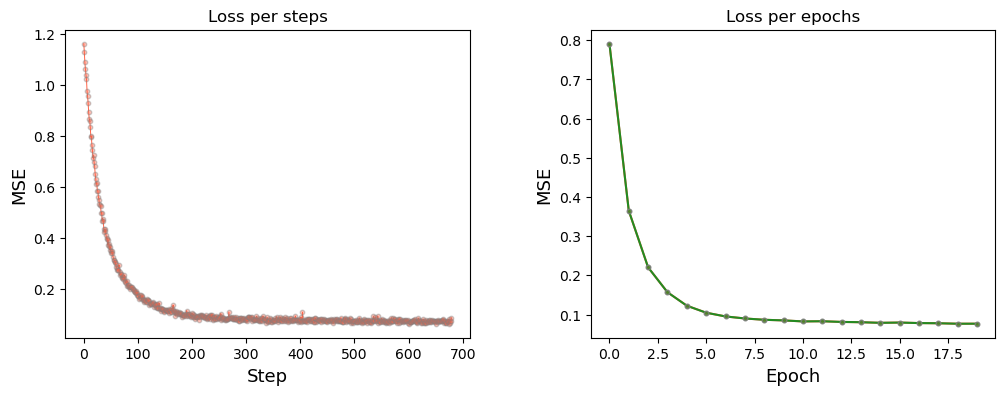

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plt.subplots_adjust(wspace=0.3)
ax[0].scatter(np.arange(len(losses_steps)), losses_steps, alpha=0.4, s=10, c='tomato', zorder=5, edgecolors='gray')
ax[0].plot(np.arange(len(losses_steps)), losses_steps, c='tomato', lw=.7)


ax[1].scatter(np.arange(len(losses_epochs)), losses_epochs, alpha=0.7, s=10, c='tomato', zorder=5, edgecolors='gray')
ax[1].plot(np.arange(len(losses_epochs)), losses_epochs, c='tomato', label='Training')
ax[1].scatter(np.arange(len(losses_epochs)), losses_epochs, alpha=0.7, s=10, c='forestgreen', zorder=5, edgecolors='gray')
ax[1].plot(np.arange(len(losses_epochs)), losses_epochs, c='forestgreen', label='Validation')

[axe.set_ylabel('MSE', fontsize=13) for axe in ax]
ax[0].set_xlabel('Step', fontsize=13)
ax[1].set_xlabel('Epoch', fontsize=13)

ax[0].set_title('Loss per steps')
ax[1].set_title('Loss per epochs');

Our model is learning!

# Testing

We can now show what our train mode does, both in the training set and testing set:

In [ ]:
model.eval()
preds = model(x_train).detach().numpy()

We show here the first 100 genes of the first patient, ground truth and predicted. You can see that our model is not perfect, but still reconstruct the global shape of the gene expression

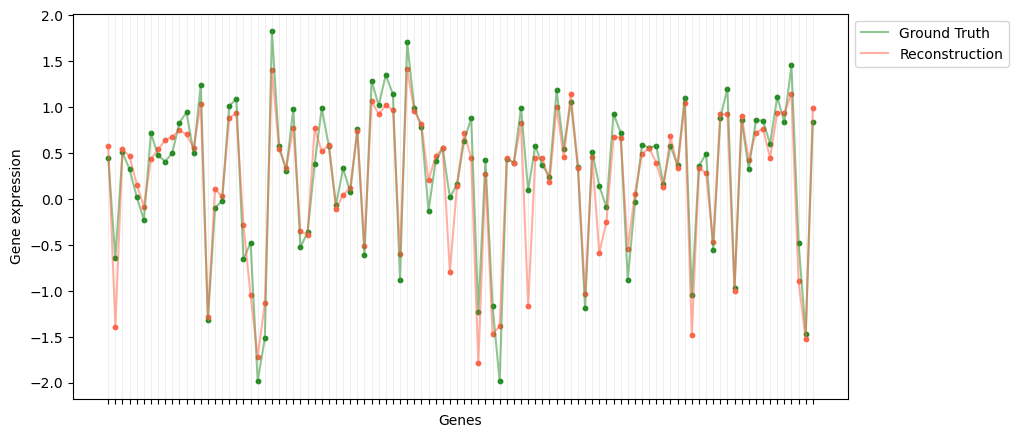

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(x_train[0, :100], c='forestgreen', alpha=0.5, label='Ground Truth')
plt.scatter(np.arange(100), x_train[0, :100], c='forestgreen', s=10)

plt.plot(preds[0, :100], alpha=0.5, c='tomato', label='Reconstruction')
plt.scatter(np.arange(100), preds[0, :100], c='tomato', s=10)
plt.xticks(np.arange(100), labels=['']*100)
plt.grid(axis='x', alpha=0.2)
plt.xlabel('Genes')
plt.ylabel('Gene expression')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left');

We show, for training and testing, what our model predict: we expect the value btween 0 and 1 predited to be higher for tumour (ground truth 1) than for healthy (ground truth 0).dd

# latent space inspection

We've shown that our reconstruction looked ok, but let's try to see if we are ineed able distinguish the subtypes, in the reconstruction but also in thge latent spacem

In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [20]:
def compute_pca(input,
                n_components=64,
                filtering=500,
                norm=True,
                norm_before=False):

    ''' Compute the n_components PCA of an input,
        filtering the most variant dims if necessary

        Parameters:
            - intput: numpy array (n_samples, n_dims); the array to PCA,
                      n_dims being the dimension you want to reduce
            - n_components: int, the number of components to return
            - filtering: bool or int; if not None, filters the filtering most variant dims before applying the PCA
        Returns:
            components: np.array(n_samples, n_components); the n_components returned by the PCA
    '''
    # print(np.shape(input))
    if n_components:
        pca = PCA(n_components=n_components)

    if norm & norm_before:
        scaler = StandardScaler()
        input = scaler.fit_transform(input)

    if filtering:
        stds = np.std(input, axis=0)
        max_stds = np.argsort(stds)[::-1]
        # print(np.shape(max_stds))
        if np.shape(input)[1] == 64:
            filtering = np.shape(input)[1]
        input = input[:, max_stds[:filtering]]

    if (norm) & (not norm_before):
        scaler = StandardScaler()
        input = scaler.fit_transform(input)

    pca.fit(input.T)
    explained_var = pca.explained_variance_ratio_
    components = pca.components_.T[:, :n_components]
    return components, explained_var

Because our model is a LEGO model, we can just use the trained Encoder brick to get the LS:

In [21]:
LS = model.Encoder(x_train).detach().numpy()

Compute the PCA in the input, LS and reconstruction

In [22]:
pc, exp_var = compute_pca(x_train, filtering=False)
pc_LS, exp_var_LS = compute_pca(LS, filtering=False)
pc_rec, exp_var_rec = compute_pca(preds, filtering=False)


WE are going to color code the first two PC of the PCAS by the subtypes

In [23]:
annots = pd.read_csv(f'{path}/BRCA_annotations.tsv', sep='\t')
annots = annots.iloc[np.where(annots['cohort'] == 'TCGA')[0]]
subtypes = np.array(annots['PAM50'].values)
subtypes_unique = list(set(subtypes))

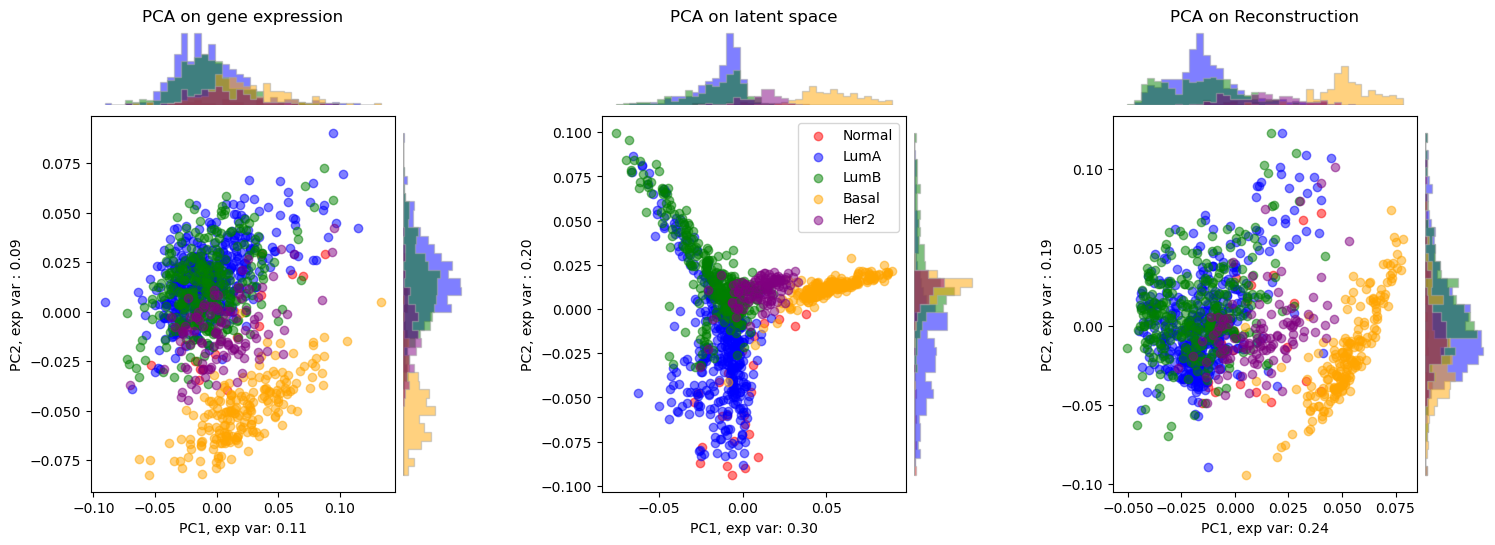

In [24]:
colors = ['red', 'blue', 'green', 'orange', 'purple']
bins = 40
fig = plt.figure(figsize=(18, 6))  # width > height, adjust for square scatters
gs = gridspec.GridSpec(2, 8, width_ratios=[5, 1, 2, 5, 1, 2, 5, 1], height_ratios=[1,5],
                       wspace=0.05, hspace=0.05)

# Left plot
ax_scatter1 = plt.subplot(gs[1,0])
ax_histx1   = plt.subplot(gs[0,0], sharex=ax_scatter1)
ax_histy1   = plt.subplot(gs[1,1], sharey=ax_scatter1)

# middle plot
ax_scatter2 = plt.subplot(gs[1,3])
ax_histx2   = plt.subplot(gs[0,3], sharex=ax_scatter2)
ax_histy2   = plt.subplot(gs[1,4], sharey=ax_scatter2)

# Right plot
ax_scatter3 = plt.subplot(gs[1,6])
ax_histx3   = plt.subplot(gs[0,6], sharex=ax_scatter3)
ax_histy3   = plt.subplot(gs[1,7], sharey=ax_scatter3)

axes_list = [
    (ax_scatter1, ax_histx1, ax_histy1, pc, exp_var),
    (ax_scatter2, ax_histx2, ax_histy2, pc_LS, exp_var_LS),
    (ax_scatter3, ax_histx3, ax_histy3, pc_rec, exp_var_rec)
]

l = 0
for ax_scatter, ax_histx, ax_histy, data, var in axes_list:
    # Scatter
    l += 1
    for j, subtype in enumerate(subtypes_unique):
        ids = np.where(subtypes == subtype)[0]
        ax_scatter.scatter(data[ids,0], data[ids,1], alpha=0.5, color=colors[j], label=subtype)
    
    # X histogram
    for j, subtype in enumerate(subtypes_unique):
        ids = np.where(subtypes == subtype)[0]
        ax_histx.hist(data[ids,0], bins=bins, range=(data[:,0].min(), data[:,0].max()),
                      color=colors[j], alpha=0.5, histtype='step', fill=True, edgecolor='darkgray')
    ax_histx.axis('off')
    
    # Y histogram
    for j, subtype in enumerate(subtypes_unique):
        ids = np.where(subtypes == subtype)[0]
        ax_histy.hist(data[ids,1], bins=bins, orientation='horizontal',
                      range=(data[:,1].min(), data[:,1].max()),
                      color=colors[j], alpha=0.5, histtype='step', fill=True, edgecolor='darkgray')
    ax_histy.axis('off')

    ax_scatter.set_xlabel(f'PC1, exp var: {var[0]:.2f}'); ax_scatter.set_ylabel(f'PC2, exp var : {var[1]:.2f}')

ax_scatter2.legend()
ax_histx1.set_title('PCA on gene expression')
ax_histx2.set_title('PCA on latent space')
ax_histx3.set_title('PCA on Reconstruction');

You can see that even without giving any information about the breast cancer subtypes, our model found a 64 dimension embeddings that spearate better these subtypes than the PCA on the whole genome!